#Data Extraction and Master Matrix Preparation

In [1]:
import pandas as pd
import numpy as np

# Load the dataframes
s1 = pd.read_excel("Survey1.xlsx")
s2 = pd.read_excel("Survey2.xlsx")

# Define the list of 11 string names for the features
pedf_names = [
    "1. Shading Devices",
    "2. Mass Self-shading",
    "3. Geometry Self-shading",
    "4. Surface Self-shading",
    "5. Double Skin (Opaque)",
    "6. Vegetative Wall",
    "7. Double Vegetated Wall",
    "8. Kinetic facade",
    "9. BIPV walls",
    "10. Evaporative Porous Blocks",
    "11. Double Skin Evaporative",
]

# Get the actual column headers from the dataframes (they are strings)
s1_headers = list(s1.columns)
s2_headers = list(s2.columns)

# --- Criterion 1 (Usage Frequency) ---
# Extracts from s1 using column indices list(range(7, 17)). Converts them to numeric, and calculates the mean score for each of the 11 columns.
# Adjusted range to get 11 columns (indices 7 to 17 inclusive) to match pedf_names length.
c1_col_names = s1_headers[7:18]
s1[c1_col_names] = s1[c1_col_names].apply(pd.to_numeric, errors='coerce')
c1_means = s1[c1_col_names].mean().values

# --- Criterion 2 (Difficulties Pct) ---
# Extracts from s1 using column indices list(range(19, 29)).
# Note that these columns contain textual categorical data from checkbox responses.
# For each of these 11 columns, calculate the percentage of respondents (0 to 100) who experienced any friction.
# A row should count as having a difficulty if it contains any text other than exactly 'No Difficulties'.
# Be sure to handle missing values (NaN) and text parsing carefully so that entries containing a difficulty
# alongside 'No Difficulties' are still flagged as a difficulty.
# Adjusted range to get 11 columns (indices 19 to 29 inclusive) to match pedf_names length.
c2_col_names = s1_headers[19:30]

c2_percentages = []
for col in c2_col_names:
    # Function to check for friction
    def check_friction(response):
        if pd.isna(response):
            return False # NaN means no response, so no friction
        response_str = str(response).strip().lower()
        # A response indicates friction if it's not exactly 'no difficulties'
        return response_str != 'no difficulties'

    friction_counts = s1[col].apply(check_friction).sum()
    total_valid_responses = s1[col].count() # Count of non-NaN values
    percentage = (friction_counts / total_valid_responses) * 100 if total_valid_responses > 0 else 0
    c2_percentages.append(percentage)

c2_percentages = np.array(c2_percentages)

# --- Criterion 3 (Tool Need) ---
# Extracts from s1 using column indices list(range(30, 40)). Converts them to numeric, and calculates the mean score for each of the 11 columns.
# Adjusted range to get 11 columns (indices 30 to 40 inclusive) to match pedf_names length.
c3_col_names = s1_headers[30:41]
s1[c3_col_names] = s1[c3_col_names].apply(pd.to_numeric, errors='coerce')
c3_means = s1[c3_col_names].mean().values

# --- Criterion 4 (Expert Performance Score) ---
# Extracts from s2 using column indices list(range(5, 16)). Converts them to numeric, and calculates the mean score for each of the 11 columns.
c4_col_names = s2_headers[5:16]
s2[c4_col_names] = s2[c4_col_names].apply(pd.to_numeric, errors='coerce')
c4_means = s2[c4_col_names].mean().values

# --- Matrix Consolidation ---
# Combines these 4 vectors of length 11 into a single pandas DataFrame called master_matrix
master_matrix = pd.DataFrame(
    {
        "C1_Frequency": c1_means,
        "C2_Difficulties_Pct": c2_percentages,
        "C3_Tool_Need": c3_means,
        "C4_Expert_Score": c4_means,
    },
    index=pedf_names,
)

# Display the master matrix (optional, for verification)
print(master_matrix)

                               C1_Frequency  C2_Difficulties_Pct  \
1. Shading Devices                 4.927007            77.737226   
2. Mass Self-shading               4.864964            55.109489   
3. Geometry Self-shading           3.551095            77.737226   
4. Surface Self-shading            3.477941            88.148148   
5. Double Skin (Opaque)            4.397810            80.291971   
6. Vegetative Wall                 3.456204            95.255474   
7. Double Vegetated Wall           2.500000            99.635036   
8. Kinetic facade                  1.934307            98.905109   
9. BIPV walls                      2.343066            92.700730   
10. Evaporative Porous Blocks      2.383212            95.620438   
11. Double Skin Evaporative        1.905109            95.620438   

                               C3_Tool_Need  C4_Expert_Score  
1. Shading Devices                 5.978102         6.928571  
2. Mass Self-shading               5.390511         6.214

# Decision Matrix Heatmap

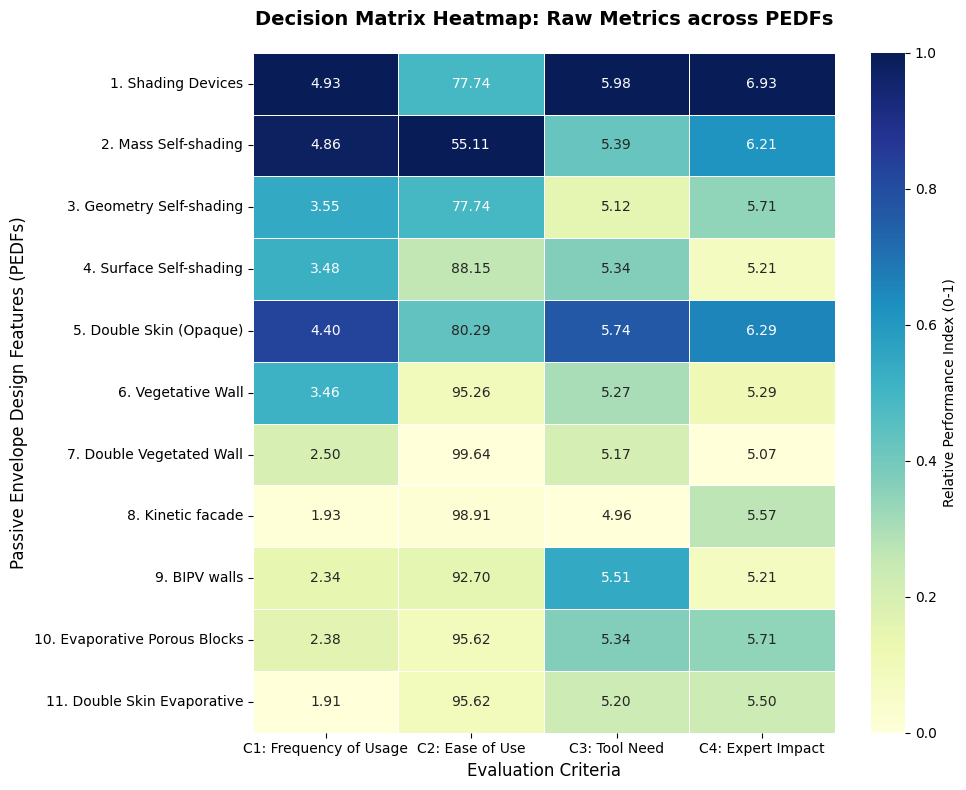

In [2]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare data: Normalize the matrix for color consistency, but keep raw values for labels
# Benefit: High value = darker; Cost (C2): Low value = darker
norm_matrix = (master_matrix - master_matrix.min()) / (master_matrix.max() - master_matrix.min())
# Invert C2 so that 'better' performance (lower difficulty) shows as a higher intensity
norm_matrix['C2_Difficulties_Pct'] = 1 - norm_matrix['C2_Difficulties_Pct']

# 2. Setup labels
clean_labels = ["C1: Frequency of Usage", "C2: Ease of Use", "C3: Tool Need", "C4: Expert Impact"]

# 3. Create Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    norm_matrix,
    annot=master_matrix.round(2),
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={'label': 'Relative Performance Index (0-1)'}
)

# 4. Formatting
plt.title("Decision Matrix Heatmap: Raw Metrics across PEDFs", fontsize=14, fontweight='bold', pad=20)
plt.xticks(np.arange(len(clean_labels)) + 0.5, clean_labels, rotation=0)
plt.xlabel("Evaluation Criteria", fontsize=12)
plt.ylabel("Passive Envelope Design Features (PEDFs)", fontsize=12)

plt.tight_layout()
plt.show()

#CRITIC Weighting Engine
1. **Standard Normalization**: Initialize a normalized dataframe of the same shape. Transform every column using standard benefit min-max normalization to bring all values onto a uniform 0–1 scale:$$\text{Norm}_{ij} = \frac{x_{ij} - \min(x_j)}{\max(x_j) - \min(x_j)}$$
2. **Contrast Intensity**: Calculate the standard deviation ($\sigma_j$) for each column of this normalized matrix using native pandas.std()
3. **Intercriteria Correlation**: Compute the Pearson correlation matrix ($r_{jk}$) of the normalized columns using .corr(method='pearson').
4. **Conflict Metric**: Compute the conflict metric for each criterion $j$ as:$$\text{Conflict}_j = \sum_{k=1}^{4} (1 - r_{jk})$$
5. **Information Amount**: Calculate the total information amount for each criterion:$$I_j = \sigma_j \times \text{Conflict}_j$$
6. **Weight Generation & Error Handling**: Calculate the final weights by normalizing the information values so they sum to 1.0. If sum(I_j) == 0 (meaning there is zero variance across the data), handle this edge case safely by assigning equal weights (e.g., 0.25 for each of the 4 criteria) to prevent a downstream divide-by-zero crash.

In [3]:
def calculate_critic_weights(df):
    # 1. Standard Normalization (with cost/benefit distinction)
    cost_criteria = ['C2_Difficulties_Pct']

    norm_df = df.copy()
    for col in df.columns:
      col_range = df[col].max() - df[col].min()
      if col in cost_criteria:
        norm_df[col] = (df[col].max() - df[col]) / col_range  # cost
      else:
        norm_df[col] = (df[col] - df[col].min()) / col_range  # benefit

    # 2. Contrast Intensity
    # Calculate standard deviation (sigma_j) for each normalized column
    sigma_j = norm_df.std(ddof=0)

    # 3. Intercriteria Correlation
    # Compute Pearson correlation matrix (r_jk) of normalized columns
    corr_matrix = norm_df.corr(method='pearson')

    # 4. Conflict Metric
    # Conflict_j = sum(1 - r_jk)
    conflict_j = (1 - corr_matrix).sum()

    # 5. Information Amount
    # I_j = sigma_j * Conflict_j
    info_j = sigma_j * conflict_j

    # 6. Weight Generation & Error Handling
    # Normalize information values to sum to 1.0
    sum_info = info_j.sum()

    if sum_info == 0:
        # Edge case: zero variance across the data
        num_criteria = len(df.columns)
        weights = pd.Series(1.0 / num_criteria, index=df.columns)
    else:
        weights = info_j / sum_info

    return weights

#TOPSIS Ranking Engine

1. Vector Normalization: Compute the norm for each column such that each element is divided by the square root of the sum of squares of that column:$$\text{NormV}_{ij} = \frac{x_{ij}}{\sqrt{\sum_{i=1}^{11} x_{ij}^2}}$$

2. Weighted Normalization: Multiply each column of the vector-normalized matrix by its corresponding weight from weight_vector to construct the weighted normalized matrix $V$. Ensure the weights align explicitly with the criteria column names to prevent alignment errors.
3. Determine Ideal Solutions ($A^+$ and $A^-$): * For a 'max' goal column: $A^+$ is the maximum value in that column of $V$, and $A^-$ is the minimum value.For a 'min' goal column: $A^+$ is the minimum value in that column of $V$, and $A^-$ is the maximum value.
4. Distance Measures: Calculate the Euclidean distance of each row to the Positive Ideal Solution ($S_i^+$) and the Negative Ideal Solution ($S_i^-$).
5. Closeness Coefficient: Calculate the relative closeness coefficient for each of the 11 design features:$$C_i = \frac{S_i^-}{S_i^+ + S_i^-}$$

In [4]:
def run_topsis_engine(matrix, weight_vector, goals):
    """
    Ranks design options using the TOPSIS method.

    Args:
        matrix (pd.DataFrame): 11x4 master matrix of raw data.
        weight_vector (pd.Series): 4 weights from the CRITIC engine.
        goals (list): List of 'max' or 'min' strings for each column.

    Returns:
        pd.Series: Closeness coefficients indexed by feature names.
    """
    # 1. Vector Normalization
    # NormV_ij = x_ij / sqrt(sum(x_ij^2))
    norm_v = matrix / np.sqrt((matrix**2).sum())

    # 2. Weighted Normalization
    # Multiply each column by its weight.
    # Multiplying a DataFrame by a Series automatically aligns on column names.
    v_matrix = norm_v * weight_vector

    # 3. Determine Ideal Solutions (A+ and A-)
    ideal_best = []
    ideal_worst = []

    for i, goal in enumerate(goals):
        column_values = v_matrix.iloc[:, i]
        if goal == 'max':
            ideal_best.append(column_values.max())
            ideal_worst.append(column_values.min())
        elif goal == 'min':
            ideal_best.append(column_values.min())
            ideal_worst.append(column_values.max())

    # 4. Distance Measures (Euclidean distance to A+ and A-)
    s_plus = np.sqrt(((v_matrix - ideal_best)**2).sum(axis=1))
    s_minus = np.sqrt(((v_matrix - ideal_worst)**2).sum(axis=1))

    # 5. Closeness Coefficient
    # C_i = S_i- / (S_i+ + S_i-)
    closeness_coeff = s_minus / (s_plus + s_minus)

    # Return as pandas Series indexed by original feature names
    return closeness_coeff

#Execution Block
## Execution Block: Reliability Scaling, CRITIC Weighting, and TOPSIS Ranking

Before running CRITIC, a reliability scaling factor is applied to the master matrix
to account for differences in data source credibility across criteria. The scaling
factor is defined as:

    Reliability = 1 / SE = 1 / (std / √n) = √n / std

Where std is the standard deviation of each criterion's scores and n is the number
of respondents. This amplifies criteria with lower standard error (i.e. more
consistent, stable responses) and down-weights criteria with higher variability.
The scaling is applied uniformly across all four criteria prior to normalisation,
so CRITIC's internal variance and correlation analysis operates on reliability-
adjusted values. This approach ensures that the 14-point expert panel (C4) and
the 274-respondent architect survey (C1, C2, C3) contribute proportionally to
the final weight structure based on the statistical confidence of their responses.

CRITIC derives objective weights from the scaled matrix. TOPSIS then ranks the 11 PEDFs under each case using these weights.

Three evaluation cases are then defined, each representing a different design priority lens, as following using these precise goal configurations:

1. Case 1 (Urgent Need): all criteria treated as benefit — maximise frequency, ease, tool need, and expert performance; goals = ['max', 'max', 'max', 'max']
2. Case 2 (Emerging Tech): frequency treated as cost — prioritises PEDFs that are less commonly used but high performing; goals = ['min', 'max', 'max', 'max']
3. Case 3 (Easy Baseline): difficulty and tool need treated as cost — prioritises PEDFs that are easy to use and require minimal decision support; goals = ['max', 'min', 'min', 'max']



In [12]:
# --- Reliability Scaling ---
# Apply 1/SE scaling factor to each criterion before CRITIC
# This adjusts for statistical confidence based on sample size and variance

def apply_reliability_scaling(df, n_weights):
    scaled_df = df.copy()
    for col in df.columns:
        n = n_weights[col]
        se = df[col].std() / np.sqrt(n)
        reliability = 1 / se if se > 0 else 1
        scaled_df[col] = df[col] * reliability
    return scaled_df

# --- Sample sizes per criterion (corrected column references) ---
n_weights = {
    'C1_Frequency':        int(s1[c1_col_names].dropna(how='all').shape[0]),
    'C2_Difficulties_Pct': int(s1[c2_col_names].dropna(how='all').shape[0]),
    'C3_Tool_Need':        int(s1[c3_col_names].dropna(how='all').shape[0]),
    'C4_Expert_Score':     int(s2[c4_col_names].dropna(how='all').shape[0])
}

# --- Apply scaling and derive CRITIC weights ---
scaled_matrix = apply_reliability_scaling(master_matrix, n_weights)
weights = calculate_critic_weights(scaled_matrix)

print("Reliability-Adjusted CRITIC Weights:")
for col, w in weights.items():
    print(f"  {col}: {w*100:.1f}%")

# --- Define three evaluation cases ---
case_configs = {
    "Case 1 Ranks": ['max', 'max', 'max', 'max'],  # Urgent Need
    "Case 2 Ranks": ['min', 'max', 'max', 'max'],  # Emerging Tech
    "Case 3 Ranks": ['max', 'min', 'min', 'max']   # Easy Baseline
}

# --- Run TOPSIS for each case, storing both scores and ranks ---
rankings_data = {}
scores_data = {}  # Fix: scores_data now defined before use

for case_name, case_goals in case_configs.items():
    closeness_scores = run_topsis_engine(scaled_matrix, weights, case_goals)
    scores_data[case_name] = closeness_scores                                    # store raw scores
    rankings_data[case_name] = closeness_scores.rank(
        ascending=False, method='min'
    ).astype(int)                                                                 # store integer ranks

# --- Consolidate rankings ---
rankings_df = pd.DataFrame(rankings_data, index=pedf_names)

print("\n" + "="*60)
print("FINAL PEDF RANKING COMPARISON ACROSS THREE CASES")
print("="*60)
print(rankings_df.to_string())
print("="*60)

Reliability-Adjusted CRITIC Weights:
  C1_Frequency: 22.8%
  C2_Difficulties_Pct: 27.0%
  C3_Tool_Need: 28.1%
  C4_Expert_Score: 22.1%

FINAL PEDF RANKING COMPARISON ACROSS THREE CASES
                               Case 1 Ranks  Case 2 Ranks  Case 3 Ranks
1. Shading Devices                        1            10             2
2. Mass Self-shading                      3            11             1
3. Geometry Self-shading                  6             8             4
4. Surface Self-shading                   5             7             5
5. Double Skin (Opaque)                   2             9             3
6. Vegetative Wall                        4             6             6
7. Double Vegetated Wall                  7             5             7
8. Kinetic facade                        10             2             9
9. BIPV walls                             9             4            10
10. Evaporative Porous Blocks             8             3             8
11. Double Skin Evapora

# Distribution of survey response

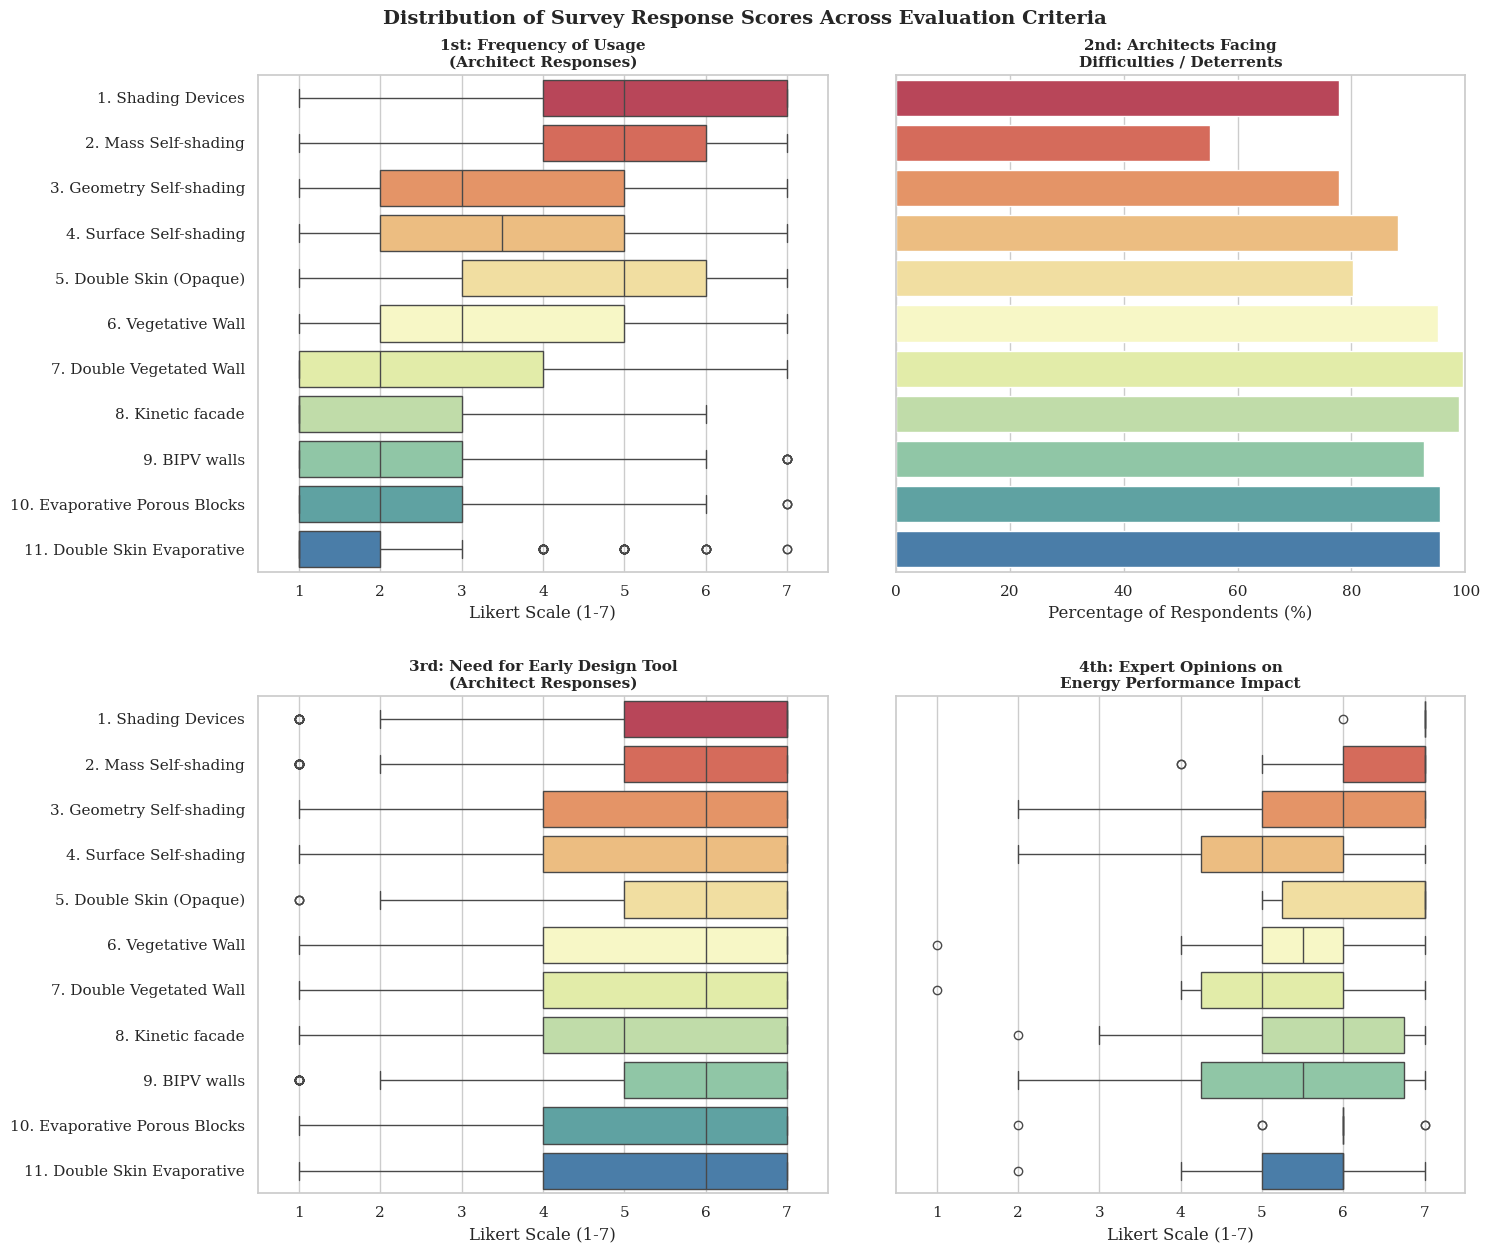

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# 1. Ensure DataFrame column names are stripped of hidden spaces
s1.columns = s1.columns.str.strip()
s2.columns = s2.columns.str.strip()

# 2. ALSO strip hidden spaces from the reference column lists to match
c1_col_names = [name.strip() for name in c1_col_names]
c3_col_names = [name.strip() for name in c3_col_names]
c4_col_names = [name.strip() for name in c4_col_names]

# Set academic typography and clean layout style
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.family": "serif", "font.size": 10})

# --- Figure canvas size optimized for 2x2 layout ---
fig, axes = plt.subplots(2, 2, figsize=(15, 13))
colors = sns.color_palette("Spectral", 11)

# Mapping dictionary to match long column names to our clean labels
c1_rename = dict(zip(c1_col_names, pedf_names))
c3_rename = dict(zip(c3_col_names, pedf_names))
c4_rename = dict(zip(c4_col_names, pedf_names))

# ----------------------------------------------------
# GRAPH 1: Frequency of Considering (BOX PLOT 1-7)
# ----------------------------------------------------
df_c1_melted = (
    s1[c1_col_names].rename(columns=c1_rename).melt(var_name="PEDF", value_name="Score")
)
df_c1_melted["Score"] = pd.to_numeric(df_c1_melted["Score"], errors="coerce")

sns.boxplot(
    data=df_c1_melted,
    x="Score",
    y="PEDF",
    hue="PEDF",
    order=pedf_names,
    ax=axes[0, 0],
    palette=colors,
    orient="h",
    legend=False,
)
axes[0, 0].set_title(
    "1st: Frequency of Usage\n(Architect Responses)", fontsize=11, fontweight="bold"
)
axes[0, 0].set_xlabel("Likert Scale (1-7)")
axes[0, 0].set_ylabel("")
axes[0, 0].set_xlim(0.5, 7.5)

# ----------------------------------------------------
# GRAPH 2: Percentage Reporting Difficulty (BAR CHART 0-100%)
# ----------------------------------------------------
sns.barplot(
    x=c2_percentages,
    y=pedf_names,
    hue=pedf_names,
    order=pedf_names,
    ax=axes[0, 1],
    palette=colors,
    orient="h",
    legend=False,
)
axes[0, 1].set_title(
    "2nd: Architects Facing\nDifficulties / Deterrents", fontsize=11, fontweight="bold"
)
axes[0, 1].set_xlabel("Percentage of Respondents (%)")
axes[0, 1].set_ylabel("")
axes[0, 1].set_xlim(0, 100)
axes[0, 1].set_yticklabels([])

# ----------------------------------------------------
# GRAPH 3: Necessity for Design Tool (BOX PLOT 1-7)
# ----------------------------------------------------
df_c3_melted = (
    s1[c3_col_names].rename(columns=c3_rename).melt(var_name="PEDF", value_name="Score")
)
df_c3_melted["Score"] = pd.to_numeric(df_c3_melted["Score"], errors="coerce")

sns.boxplot(
    data=df_c3_melted,
    x="Score",
    y="PEDF",
    hue="PEDF",
    order=pedf_names,
    ax=axes[1, 0],
    palette=colors,
    orient="h",
    legend=False,
)
axes[1, 0].set_title(
    "3rd: Need for Early Design Tool\n(Architect Responses)",
    fontsize=11,
    fontweight="bold",
)
axes[1, 0].set_xlabel("Likert Scale (1-7)")
axes[1, 0].set_ylabel("")
axes[1, 0].set_xlim(0.5, 7.5)

# ----------------------------------------------------
# GRAPH 4: Expert Score / Energy Importance (BOX PLOT 1-7)
# ----------------------------------------------------
df_c4_melted = (
    s2[c4_col_names].rename(columns=c4_rename).melt(var_name="PEDF", value_name="Score")
)
df_c4_melted["Score"] = pd.to_numeric(df_c4_melted["Score"], errors="coerce")

sns.boxplot(
    data=df_c4_melted,
    x="Score",
    y="PEDF",
    hue="PEDF",
    order=pedf_names,
    ax=axes[1, 1],
    palette=colors,
    orient="h",
    legend=False,
)
axes[1, 1].set_title(
    "4th: Expert Opinions on\nEnergy Performance Impact", fontsize=11, fontweight="bold"
)
axes[1, 1].set_xlabel("Likert Scale (1-7)")
axes[1, 1].set_ylabel("")
axes[1, 1].set_xlim(0.5, 7.5)
axes[1, 1].set_yticklabels([])

# Overall canvas layout polish
plt.suptitle(
    "Distribution of Survey Response Scores Across Evaluation Criteria",
    fontsize=14,
    fontweight="bold",
    y=0.96,
)

plt.tight_layout()
plt.subplots_adjust(top=0.91, hspace=0.25, wspace=0.12)

# Save the plot
plt.savefig("Survey_response.png", dpi=300, bbox_inches="tight")
plt.show()

Cronbach's alpha is calculated using the following equation:$$\alpha = \frac{K}{K - 1} \left(1 - \frac{\sum_{i=1}^K \sigma_i^2}{\sigma_X^2}\right)$$
Where:$K$ is the number of questions in the group ($K = 11$ features for each of the groups).$\sigma_i^2$ is the variance of responses for the $i$-th individual question.$\sum_{i=1}^K \sigma_i^2$ is the sum of the individual variances across all 11 columns.$\sigma_X^2$ is the total variance of the composite scores (the variance of the sum score of all 11 columns calculated row-by-row for each respondent).

Running this calculation on
* Group 1 (Frequency of Usage): $\alpha \approx 0.811$
* Group 2 (Demand for Early Design Tools): $\alpha \approx 0.865$
* Group 3 (Expert Opinions on Energy Importance): $\alpha \approx 0.805$

In [14]:
import numpy as np
import pandas as pd


def calculate_cronbach_alpha(df):
    # Drop rows with missing values to ensure matrix consistency
    df_clean = df.dropna()
    K = df_clean.shape[1]

    # 1. Sum of individual column variances
    sum_item_variances = df_clean.var(ddof=1).sum()

    # 2. Variance of row-by-row total sums
    total_score_variance = df_clean.sum(axis=1).var(ddof=1)

    # 3. Apply the Cronbach's Alpha Formula
    alpha = (K / (K - 1)) * (1 - (sum_item_variances / total_score_variance))
    return alpha


# Load the data files
s1 = pd.read_excel("Survey1.xlsx")
s2 = pd.read_excel("Survey2.xlsx")

# Clean column headers
s1.columns = s1.columns.str.strip()
s2.columns = s2.columns.str.strip()
s1_headers = list(s1.columns)

# Isolate the three Likert scale question blocks (11 features each)
group1_cols = s1.columns[7:18]  # Frequency of Usage (q1)
group2_cols = s1_headers[30:41]  # Need for Design Tool (q3)
group3_cols = s2.columns[5:16]  # Expert Energy Importance Scores (q4)

# Convert to numeric to ensure math functions evaluate smoothly
g1_data = s1[group1_cols].apply(pd.to_numeric, errors="coerce")
g2_data = s1[group2_cols].apply(pd.to_numeric, errors="coerce")
g3_data = s2[group3_cols].apply(pd.to_numeric, errors="coerce")

# Calculate and display the results
print(f"Group 1 (Frequency of Usage) Alpha: {calculate_cronbach_alpha(g1_data):.3f}")
print(f"Group 2 (Need for Design Tool) Alpha: {calculate_cronbach_alpha(g2_data):.3f}")
print(f"Group 3 (Expert Importance Scores) Alpha: {calculate_cronbach_alpha(g3_data):.3f}")

Group 1 (Frequency of Usage) Alpha: 0.811
Group 2 (Need for Design Tool) Alpha: 0.865
Group 3 (Expert Importance Scores) Alpha: 0.805


# CRITIC Objective Weight Distribution

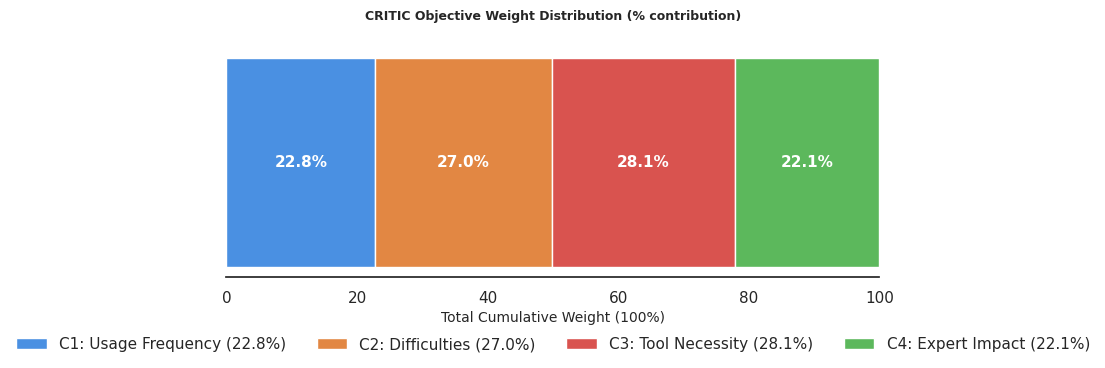

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Prepare the data from the 'weights' series calculated in the execution block
criteria_labels = ["C1: Usage Frequency", "C2: Difficulties", "C3: Tool Necessity", "C4: Expert Impact"]
# Align weight values with the labels
weight_pcts = weights.values * 100

# 2. Setup the visualization
plt.figure(figsize=(10, 4))
sns.set_theme(style="white")
colors = ["#4A90E2", "#E28743", "#D9534F", "#5CB85C"]

# 3. Create a single horizontal stacked bar
left_pos = 0
for i, (label, val) in enumerate(zip(criteria_labels, weight_pcts)):
    plt.barh("Objective Weights", val, left=left_pos, color=colors[i], label=f"{label} ({val:.1f}%)", edgecolor='white', height=0.6)
    # Add percentage text label in the middle of each segment
    plt.text(left_pos + val/2, 0, f"{val:.1f}%", va='center', ha='center', color='white', fontweight='bold', fontsize=11)
    left_pos += val

# 4. Final Formatting
plt.title("CRITIC Objective Weight Distribution (% contribution)", fontsize=9, fontweight='bold', pad=20)
plt.xlabel("Total Cumulative Weight (100%)", fontsize=10)
plt.xlim(0, 100)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=4, frameon=False)

# Remove Y-axis label as it's self-explanatory
plt.gca().get_yaxis().set_visible(False)
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

#TOPIS Performance Score

In [16]:
import pandas as pd

scores_df = pd.DataFrame(scores_data, index=pedf_names)

# --- Build display table ---
# Rename columns to cleaner case labels
display_df = scores_df.copy()
display_df.columns = ["Case 1: Urgent Need", "Case 2: Emerging Tech", "Case 3: Baseline"]

# Add rank columns for each case
for col in display_df.columns:
    rank_col = col.replace("Case", "Rank")
    display_df[rank_col] = display_df[col].rank(ascending=False, method='min').astype(int)

# Round scores to 3 decimal places
score_cols = ["Case 1: Urgent Need", "Case 2: Emerging Tech", "Case 3: Baseline"]
display_df[score_cols] = display_df[score_cols].round(3)

# Reorder columns to interleave score and rank
display_df = display_df[[
    "Case 1: Urgent Need", "Rank 1: Urgent Need",
    "Case 2: Emerging Tech", "Rank 2: Emerging Tech",
    "Case 3: Baseline", "Rank 3: Baseline"
]]

print("\n" + "="*90)
print("TOPSIS PERFORMANCE SCORES AND RANKINGS — ALL THREE CASES")
print("="*90)
print(display_df.to_string())
print("="*90)


TOPSIS PERFORMANCE SCORES AND RANKINGS — ALL THREE CASES
                               Case 1: Urgent Need  Rank 1: Urgent Need  Case 2: Emerging Tech  Rank 2: Emerging Tech  Case 3: Baseline  Rank 3: Baseline
1. Shading Devices                           0.774                    1                  0.348                     10             0.719                 2
2. Mass Self-shading                         0.587                    3                  0.170                     11             0.873                 1
3. Geometry Self-shading                     0.503                    6                  0.450                      8             0.527                 4
4. Surface Self-shading                      0.537                    5                  0.515                      7             0.425                 5
5. Double Skin (Opaque)                      0.722                    2                  0.371                      9             0.652                 3
6. Vegetative Wall

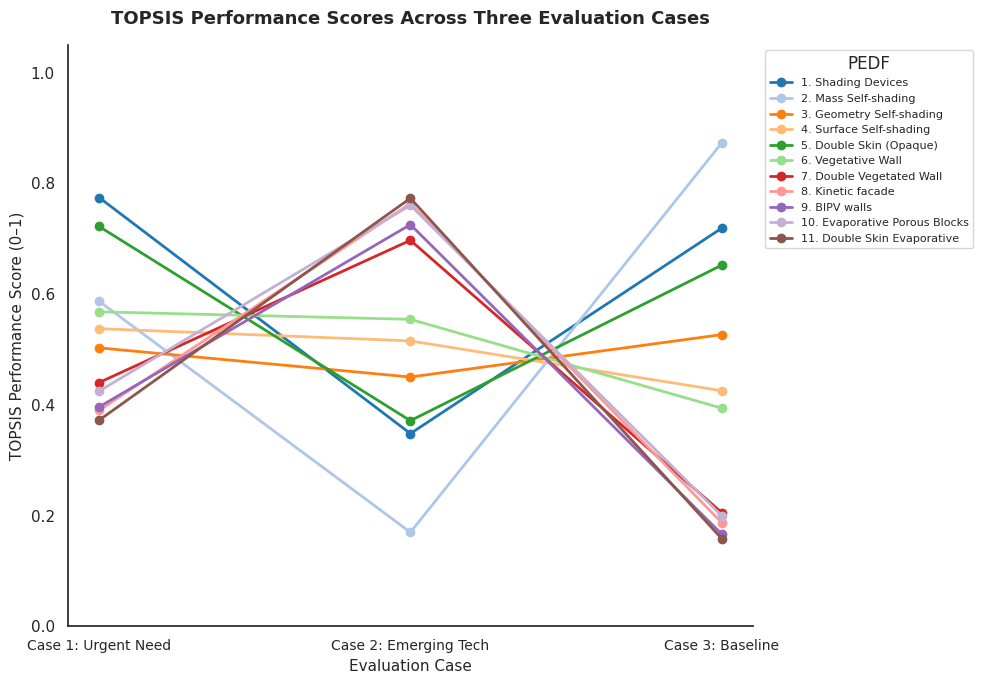

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 7))

case_labels = ["Case 1: Urgent Need", "Case 2: Emerging Tech", "Case 3: Baseline"]
x = np.arange(len(case_labels))

colors = plt.cm.tab20.colors  # 20 distinct colors, enough for 11 lines

for i, pedf in enumerate(pedf_names):
    y = scores_df.loc[pedf].values
    ax.plot(x, y, marker='o', linewidth=2, markersize=6,
            label=pedf, color=colors[i])

# Formatting
ax.set_title("TOPSIS Performance Scores Across Three Evaluation Cases",
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel("TOPSIS Performance Score (0–1)", fontsize=11)
ax.set_xlabel("Evaluation Case", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(case_labels, fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(title="PEDF", bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=8, frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()